In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet("../data/staging/market_data.parquet")
df.head(20)

,timestamp,coin_id,price,market_cap,volume
0,2025-05-03 08:00:00+00:00,aave,143.662466,2.169384e+09,1.482474e+08
1,2025-05-03 09:00:00+00:00,aave,144.180472,2.178239e+09,1.520011e+08
2,2025-05-03 10:00:00+00:00,aave,144.302779,2.180160e+09,1.528573e+08
3,2025-05-03 11:00:00+00:00,aave,142.487474,2.151036e+09,1.542045e+08
4,2025-05-03 12:00:00+00:00,aave,142.319868,2.149688e+09,1.581959e+08
5,2025-05-03 13:00:00+00:00,aave,143.566212,2.168710e+09,1.548688e+08
6,2025-05-03 14:00:00+00:00,aave,143.820629,2.172376e+09,1.496728e+08
7,2025-05-03 15:00:00+00:00,aave,144.103170,2.176248e+09,1.408627e+08
8,2025-05-03 16:00:00+00:00,aave,143.078555,2.162485e+09,1.345671e+08
9,2025-05-03 17:00:00+00:00,aave,141.420650,2.137145e+09,1.242732e+08


In [3]:
df.tail()

,timestamp,coin_id,price,market_cap,volume
816960,2026-05-14 11:00:00+00:00,zcash,408.314033,6.812123e+09,5.822203e+08
816961,2026-05-14 12:00:00+00:00,zcash,406.561118,6.787291e+09,5.770726e+08
816962,2026-05-14 13:00:00+00:00,zcash,407.595597,6.806194e+09,6.197262e+08
816963,2026-05-14 14:00:00+00:00,zcash,410.986785,6.879409e+09,6.101527e+08
816964,2026-05-14 15:00:00+00:00,zcash,432.750770,7.180644e+09,6.572102e+08


In [4]:
df.timestamp.sort_values(ascending=False)

816964   2026-05-14 15:00:00+00:00
574149   2026-05-14 15:00:00+00:00
732198   2026-05-14 15:00:00+00:00
267342   2026-05-14 15:00:00+00:00
723166   2026-05-14 15:00:00+00:00
                    ...           
656215   2025-04-28 17:00:00+00:00
206782   2025-04-28 17:00:00+00:00
66460    2025-04-28 17:00:00+00:00
589067   2025-04-28 17:00:00+00:00
75603    2025-04-28 17:00:00+00:00
Name: timestamp, Length: 816965, dtype: datetime64[us, UTC]

In [5]:
len(df)

816965

In [6]:
df.duplicated(subset=["coin_id", "timestamp"]).sum()

np.int64(0)

In [7]:
df[["price", "market_cap", "volume"]].isna().sum()

price         12004
market_cap    12004
volume        12004
dtype: int64

In [8]:
df.groupby("coin_id")["volume"].apply(lambda s: s.isna().sum()).sort_values(
    ascending=False
)

coin_id
hashnote-usyc     6184
ylds              3456
figure-heloc      1948
kucoin-shares        9
usual-usd            9
                  ... 
chainlink            2
united-stables       2
pump-fun             2
stable-2             1
canton-network       0
Name: volume, Length: 95, dtype: int64

In [9]:
grouped_count = df.groupby("coin_id")["timestamp"].agg(["min", "max", "count"])
print(grouped_count.to_markdown())

| coin_id                 | min                       | max                       |   count |
|:------------------------|:--------------------------|:--------------------------|--------:|
| aave                    | 2025-05-03 08:00:00+00:00 | 2026-05-14 15:00:00+00:00 |    9032 |
| algorand                | 2025-05-03 08:00:00+00:00 | 2026-05-14 15:00:00+00:00 |    9032 |
| aptos                   | 2025-05-03 08:00:00+00:00 | 2026-05-14 15:00:00+00:00 |    9032 |
| arbitrum                | 2025-05-03 08:00:00+00:00 | 2026-05-14 15:00:00+00:00 |    9032 |
| aster-2                 | 2025-09-19 02:00:00+00:00 | 2026-05-14 15:00:00+00:00 |    5702 |
| avalanche-2             | 2025-05-03 08:00:00+00:00 | 2026-05-14 15:00:00+00:00 |    9032 |
| beldex                  | 2025-05-03 08:00:00+00:00 | 2026-05-14 15:00:00+00:00 |    9032 |
| bfusd                   | 2025-08-14 02:00:00+00:00 | 2026-05-14 15:00:00+00:00 |    6566 |
| binancecoin             | 2025-04-28 17:00:00+00:00 | 2026

In [9]:
print(grouped_count[grouped_count["count"] >= 8700].to_markdown())

| coin_id                 | min                       | max                       |   count |
|:------------------------|:--------------------------|:--------------------------|--------:|
| aave                    | 2025-05-03 08:00:00+00:00 | 2026-05-03 09:00:00+00:00 |    8762 |
| algorand                | 2025-05-03 08:00:00+00:00 | 2026-05-03 09:00:00+00:00 |    8762 |
| aptos                   | 2025-05-03 08:00:00+00:00 | 2026-05-03 09:00:00+00:00 |    8762 |
| arbitrum                | 2025-05-03 08:00:00+00:00 | 2026-05-03 09:00:00+00:00 |    8762 |
| avalanche-2             | 2025-05-03 08:00:00+00:00 | 2026-05-03 09:00:00+00:00 |    8762 |
| beldex                  | 2025-05-03 08:00:00+00:00 | 2026-05-03 09:00:00+00:00 |    8762 |
| binancecoin             | 2025-04-28 17:00:00+00:00 | 2026-05-03 09:00:00+00:00 |    8873 |
| bitcoin                 | 2025-04-28 17:00:00+00:00 | 2026-05-03 09:00:00+00:00 |    8873 |
| bitcoin-cash            | 2025-05-01 13:00:00+00:00 | 2026

In [10]:
for coin_id, coin_df in df.groupby("coin_id"):
    full_range = pd.date_range(
        start=coin_df["timestamp"].min(),
        end=coin_df["timestamp"].max(),
        freq="h",
        tz="UTC",
    )

    missing = full_range.difference(coin_df["timestamp"])

    print(coin_id, "missing hours:", len(missing))

aave missing hours: 0
algorand missing hours: 0
aptos missing hours: 0
arbitrum missing hours: 0
aster-2 missing hours: 0
avalanche-2 missing hours: 0
beldex missing hours: 0
bfusd missing hours: 0
binancecoin missing hours: 0
bitcoin missing hours: 0
bitcoin-cash missing hours: 0
bitget-token missing hours: 0
bittensor missing hours: 0
bonk missing hours: 0
canton-network missing hours: 0
cardano missing hours: 0
chainlink missing hours: 0
cosmos missing hours: 0
crypto-com-chain missing hours: 0
dai missing hours: 0
dexe missing hours: 0
dogecoin missing hours: 0
ethena missing hours: 0
ethena-usde missing hours: 0
ethereum missing hours: 0
ethereum-classic missing hours: 0
falcon-finance missing hours: 0
figure-heloc missing hours: 0
filecoin missing hours: 0
flare-networks missing hours: 0
gatechain-token missing hours: 0
gho missing hours: 0
global-dollar missing hours: 0
hash-2 missing hours: 0
hashnote-usyc missing hours: 0
hedera-hashgraph missing hours: 0
htx-dao missing hours

<Axes: xlabel='timestamp'>

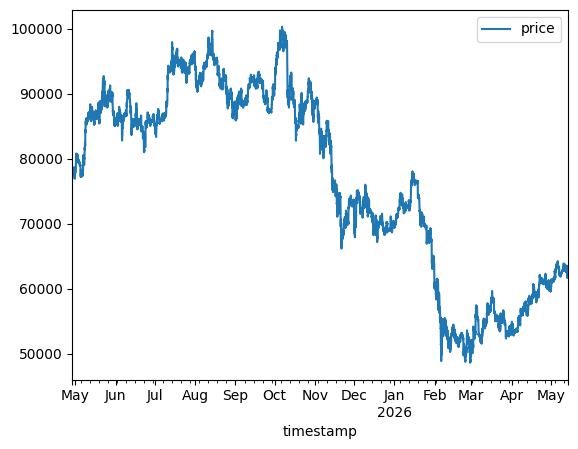

In [11]:
df[df["coin_id"] == "bitcoin"].plot.line(x="timestamp", y="price")